In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from causalimpact import CausalImpact

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [2]:
df = pd.read_csv('online_retail_II.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
df['Revenue'] = df['Quantity'] * df['Price']

daily = df.groupby(df['InvoiceDate'].dt.date)['Revenue'].sum().reset_index()
daily.columns = ['Date', 'Revenue']
daily['Date'] = pd.to_datetime(daily['Date'])
daily = daily.sort_values('Date').reset_index(drop=True)

print(f"기간: {daily['Date'].min().date()} ~ {daily['Date'].max().date()}")
print(f"총 {len(daily)}일치 데이터")

기간: 2009-12-01 ~ 2011-12-09
총 604일치 데이터


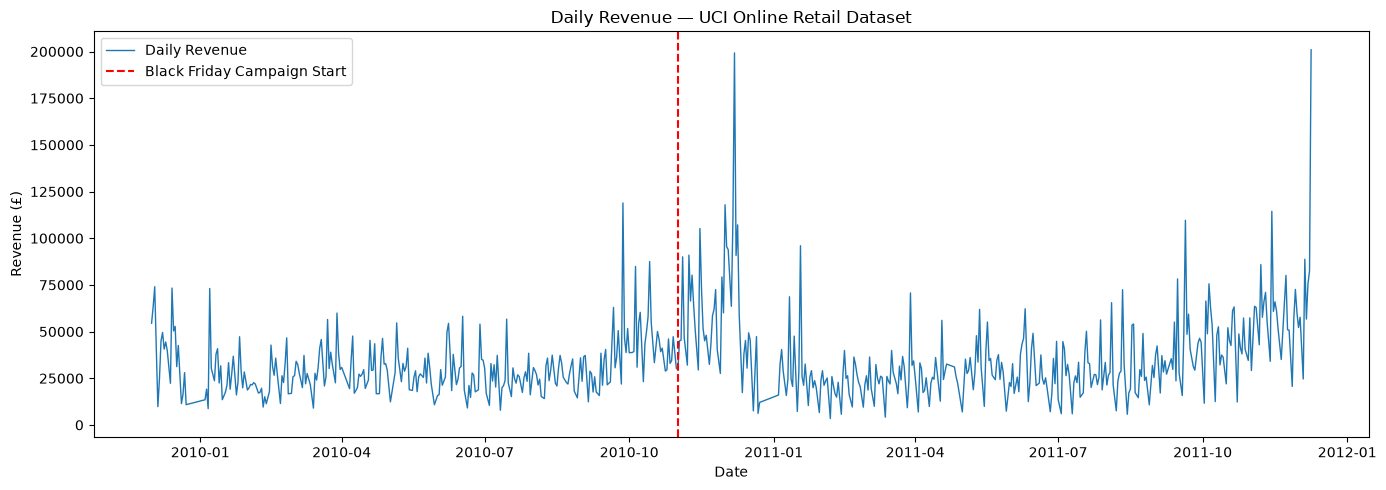

캠페인 전 일평균: £30,757
캠페인 후 일평균: £37,993
단순 전후 비교: +23.5%
→ 단순 비교만으로는 이게 캠페인 효과인지 계절성인지 알 수 없음


In [3]:
campaign_start = pd.Timestamp('2010-11-01')

plt.figure(figsize=(14, 5))
plt.plot(daily['Date'], daily['Revenue'], linewidth=1, label='Daily Revenue')
plt.axvline(x=campaign_start, color='red', linestyle='--', linewidth=1.5, label='Black Friday Campaign Start')
plt.title('Daily Revenue — UCI Online Retail Dataset')
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.legend()
plt.tight_layout()
plt.savefig('fig_01_daily_revenue.png', dpi=150)
plt.show()

pre = daily[daily['Date'] < campaign_start]['Revenue'].mean()
post = daily[daily['Date'] >= campaign_start]['Revenue'].mean()
print(f"캠페인 전 일평균: £{pre:,.0f}")
print(f"캠페인 후 일평균: £{post:,.0f}")
print(f"단순 전후 비교: {((post-pre)/pre*100):+.1f}%")
print("→ 단순 비교만으로는 이게 캠페인 효과인지 계절성인지 알 수 없음")

C:\api\k\online_retail_test\causal_env\Lib\site-packages\causalimpact\misc.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_mu = data_mu[0]
C:\api\k\online_retail_test\causal_env\Lib\site-packages\causalimpact\misc.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_sd = data_sd[0]
C:\api\k\online_retail_test\causal_env\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


                                Average           Cumulative
Actual                            37993             12575827
Predicted                         36887             12209750
95% CI                   [14097, 59676]  [4666418, 19753083]
                                                            
Absolute Effect                    1105               366077
95% CI                  [23895, -21683]  [7909409, -7177255]
                                                            
Relative Effect                    3.0%                 3.0%
95% CI                  [64.8%, -58.8%]      [64.8%, -58.8%]
                                                            
P-value                            0.1%                     
Prob. of Causal Effect            99.9%                     
None


C:\api\k\online_retail_test\causal_env\Lib\site-packages\causalimpact\analysis.py:954: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


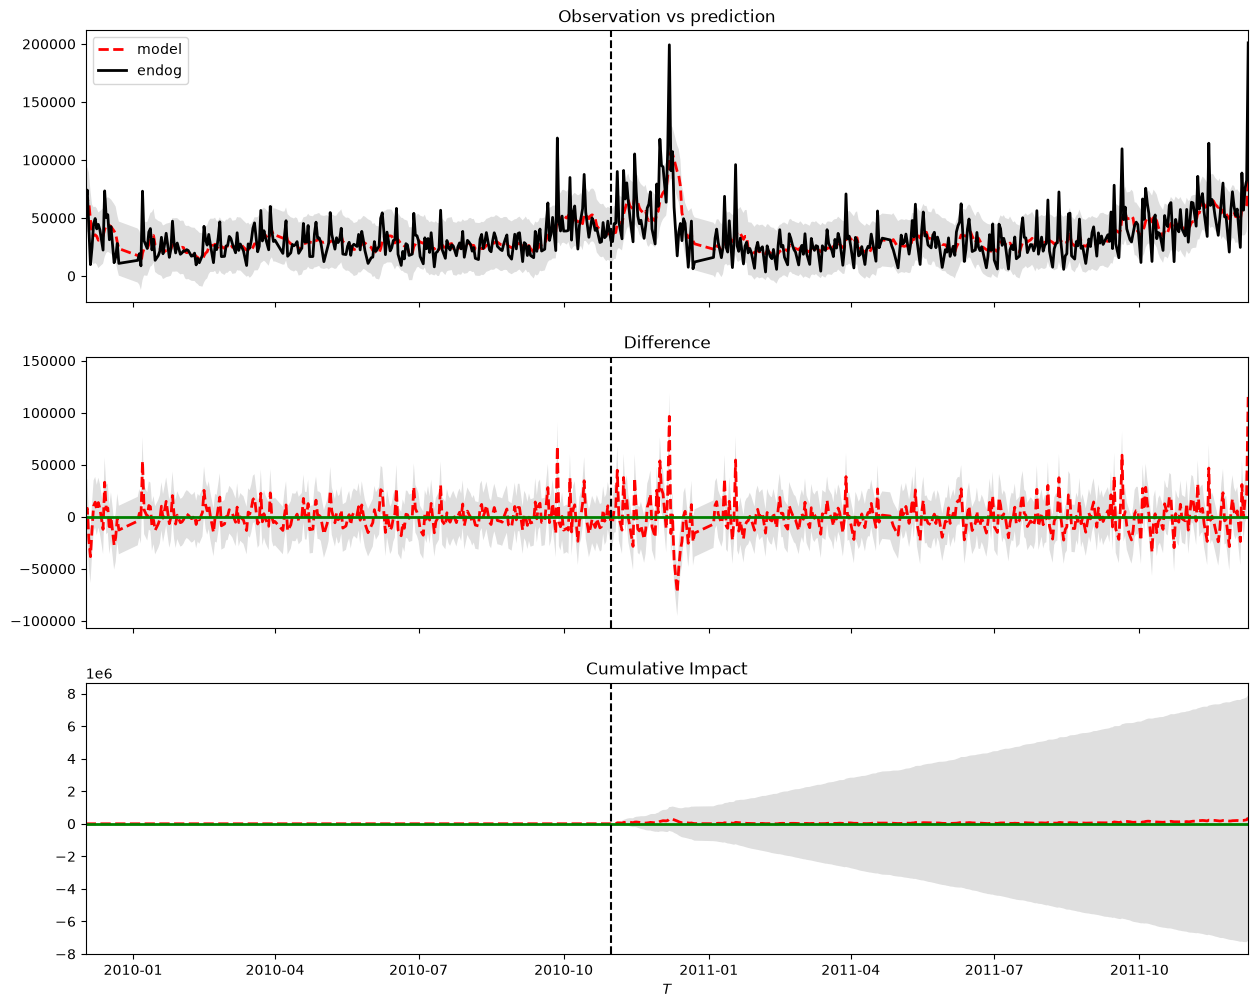

In [8]:
ci_data = daily.set_index('Date')[['Revenue']].copy()
ci_data['Revenue_MA7'] = ci_data['Revenue'].rolling(7, min_periods=1).mean()

pre_period = ['2009-12-01', '2010-10-31']
post_period = ['2010-11-01', '2011-12-09']

ci = CausalImpact(ci_data, pre_period, post_period)
ci.run()
print(ci.summary())

# 저장 먼저, show는 나중에
import matplotlib
matplotlib.use('Agg')  # 백엔드 변경
ci.plot()
plt.savefig('fig_02_causal_impact.png', dpi=150, bbox_inches='tight')
plt.close()

# 다시 interactive 백엔드로
matplotlib.use('inline')
ci.plot()
plt.show()

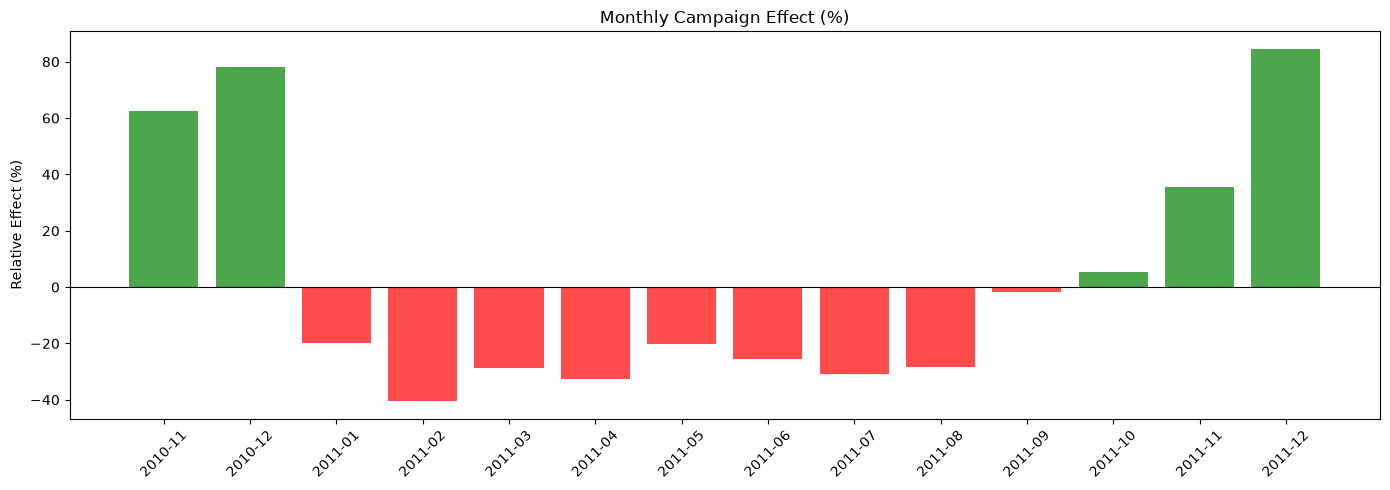

In [5]:
post_df = daily[daily['Date'] >= campaign_start].copy()
pre_df = daily[daily['Date'] < campaign_start].copy()

pre_df['t'] = np.arange(len(pre_df))
coeffs = np.polyfit(pre_df['t'], pre_df['Revenue'], 1)

post_df = post_df.copy()
post_df['t'] = np.arange(len(pre_df), len(pre_df) + len(post_df))
post_df['Predicted'] = np.polyval(coeffs, post_df['t'])
post_df['Effect'] = post_df['Revenue'] - post_df['Predicted']

post_df['Month'] = post_df['Date'].dt.to_period('M')
monthly = post_df.groupby('Month').agg(
    Actual=('Revenue', 'sum'),
    Predicted=('Predicted', 'sum'),
    Effect=('Effect', 'sum')
).reset_index()
monthly['Relative_Effect'] = monthly['Effect'] / monthly['Predicted'] * 100
monthly['Month_str'] = monthly['Month'].astype(str)

colors = ['green' if x > 0 else 'red' for x in monthly['Relative_Effect']]
plt.figure(figsize=(14, 5))
plt.bar(monthly['Month_str'], monthly['Relative_Effect'], color=colors, alpha=0.7)
plt.axhline(y=0, color='black', linewidth=0.8)
plt.title('Monthly Campaign Effect (%)')
plt.ylabel('Relative Effect (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fig_03_monthly_effect.png', dpi=150)
plt.show()

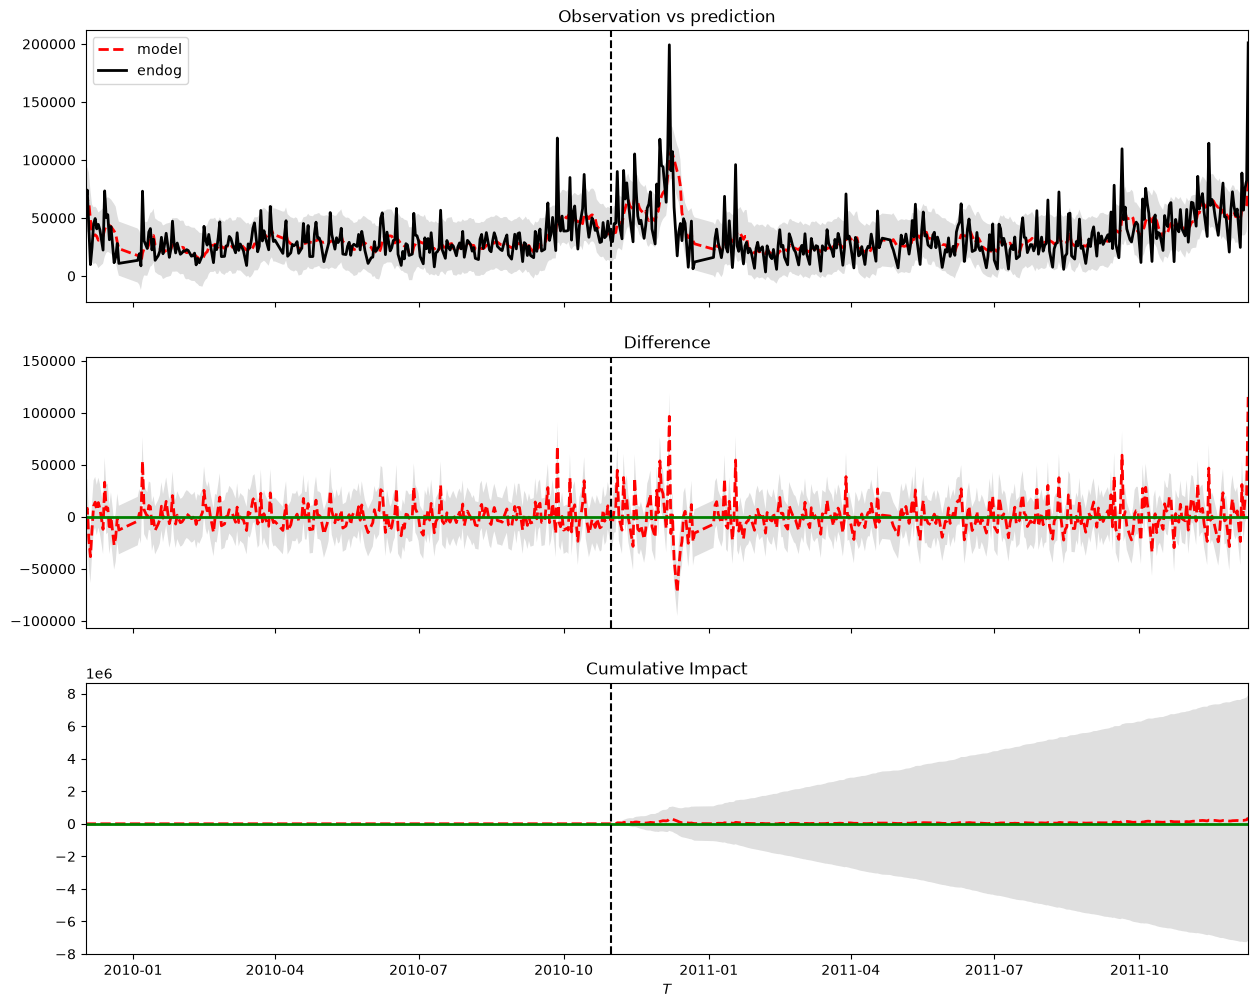

<Figure size 1400x1000 with 0 Axes>

In [6]:
# CausalImpact 플롯 저장 수정
ci.plot()
fig = plt.gcf()
fig.set_size_inches(14, 10)
fig.savefig('fig_02_causal_impact.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
import statsmodels.formula.api as smf

# 국가별 일별 revenue 집계
df_did = df.copy()
df_did['Date'] = df_did['InvoiceDate'].dt.date
df_did['Date'] = pd.to_datetime(df_did['Date'])
df_did['Revenue'] = df_did['Quantity'] * df_did['Price']

# UK vs 비UK
df_did['is_uk'] = (df_did['Country'] == 'United Kingdom').astype(int)

daily_did = df_did.groupby(['Date', 'is_uk'])['Revenue'].sum().reset_index()

# 캠페인 기간 변수
campaign_start = pd.Timestamp('2010-11-01')
daily_did['post'] = (daily_did['Date'] >= campaign_start).astype(int)

# DiD 변수: treated(UK) * post
daily_did['did'] = daily_did['is_uk'] * daily_did['post']

print(daily_did.head(10))
print(f"\nUK 데이터: {daily_did[daily_did['is_uk']==1].shape[0]}일")
print(f"비UK 데이터: {daily_did[daily_did['is_uk']==0].shape[0]}일")

        Date  is_uk   Revenue  post  did
0 2009-12-01      0   6682.37     0    0
1 2009-12-01      1  47831.13     0    0
2 2009-12-02      0   7297.32     0    0
3 2009-12-02      1  56055.19     0    0
4 2009-12-03      0   1151.55     0    0
5 2009-12-03      1  72886.36     0    0
6 2009-12-04      0   2615.97     0    0
7 2009-12-04      1  38116.95     0    0
8 2009-12-05      0    760.69     0    0
9 2009-12-05      1   9042.36     0    0

UK 데이터: 604일
비UK 데이터: 573일


                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.420
Model:                            OLS   Adj. R-squared:                  0.418
Method:                 Least Squares   F-statistic:                     282.8
Date:                Fri, 10 Jul 2026   Prob (F-statistic):          4.37e-138
Time:                        17:42:31   Log-Likelihood:                -12944.
No. Observations:                1177   AIC:                         2.590e+04
Df Residuals:                    1173   BIC:                         2.592e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4773.9294    900.826      5.300      0.0

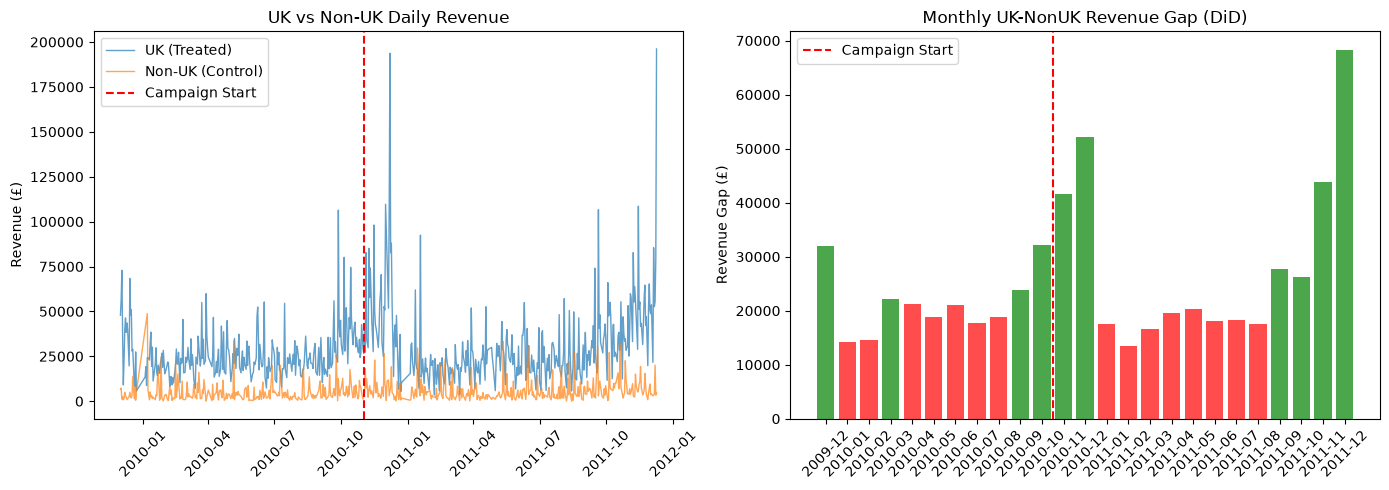

In [10]:
# DiD 회귀분석
model = smf.ols('Revenue ~ is_uk + post + did', data=daily_did).fit()
print(model.summary())

# 핵심 결과만 따로 출력
did_coef = model.params['did']
did_pvalue = model.pvalues['did']
print(f"\n=== DiD 핵심 결과 ===")
print(f"DiD 계수 (캠페인 순수 효과): £{did_coef:,.0f}")
print(f"P-value: {did_pvalue:.4f}")
print(f"통계적 유의성: {'유의함 (p<0.05)' if did_pvalue < 0.05 else '유의하지 않음 (p>=0.05)'}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# UK vs 비UK 트렌드
uk = daily_did[daily_did['is_uk'] == 1]
non_uk = daily_did[daily_did['is_uk'] == 0]

axes[0].plot(uk['Date'], uk['Revenue'], label='UK (Treated)', linewidth=1, alpha=0.7)
axes[0].plot(non_uk['Date'], non_uk['Revenue'], label='Non-UK (Control)', linewidth=1, alpha=0.7)
axes[0].axvline(x=campaign_start, color='red', linestyle='--', linewidth=1.5, label='Campaign Start')
axes[0].set_title('UK vs Non-UK Daily Revenue')
axes[0].set_ylabel('Revenue (£)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# 월별 DiD 효과
daily_did['Month'] = daily_did['Date'].dt.to_period('M')
monthly_did = daily_did.groupby(['Month', 'is_uk'])['Revenue'].mean().unstack()
monthly_did.columns = ['Non-UK', 'UK']
monthly_did['Gap'] = monthly_did['UK'] - monthly_did['Non-UK']
monthly_did['Month_str'] = monthly_did.index.astype(str)

colors = ['green' if x > monthly_did['Gap'][:11].mean() else 'red' 
          for x in monthly_did['Gap']]
axes[1].bar(monthly_did['Month_str'], monthly_did['Gap'], color=colors, alpha=0.7)
axes[1].axvline(x=10.5, color='red', linestyle='--', linewidth=1.5, label='Campaign Start')
axes[1].set_title('Monthly UK-NonUK Revenue Gap (DiD)')
axes[1].set_ylabel('Revenue Gap (£)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fig_04_did_analysis.png', dpi=150, bbox_inches='tight')
plt.show()